In [1]:
import os
import json
import time
import joblib
import random 
import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.text import tokenizer_from_json
from tensorflow.keras.preprocessing.sequence import pad_sequences
from openai import OpenAI

from sklearn.feature_extraction.text import TfidfVectorizer

### Config

In [2]:
DATA_FILE = "../data/processed/cleaned_emotions_shared.csv"
SPLIT_FILE = "../data/splits/shared_split.json"

ML_METADATA_FILE = "../models/ml_all_models_metadata.json"
DL_MODEL_FILE = "../models/bilstm_model.keras"
DL_META_FILE = "../models/dl_metadata.json"
TOKENIZER_FILE = "../models/tokenizer.json"

LLM_NAME = "deepseek"
LLM_MODEL = "deepseek-r1:8b"

OUTPUT_PRED_FILE = f"../data/processed/hybrid_{LLM_NAME}_predictions.csv"
OUTPUT_SUMMARY_FILE = f"../data/processed/hybrid_{LLM_NAME}_summary.csv"
OUTPUT_PER_CLASS_FILE = f"../data/processed/hybrid_{LLM_NAME}_per_class.csv"
OUTPUT_MCNEMAR_FILE = f"../data/processed/mcnemar_{LLM_NAME}_results.csv"

BERT_PRED_FILE = "../data/processed/bert_test_predictions.csv"
ROBERTA_PRED_FILE = "../data/processed/roberta_test_predictions.csv"
CLINICALBERT_PRED_FILE = "../data/processed/clinicalbert_test_predictions.csv"

TRANSFORMER_FILES = {
    "BERT": "../data/processed/bert_test_predictions.csv",
    "RoBERTa": "../data/processed/roberta_test_predictions.csv",
    "ClinicalBERT": "../data/processed/clinicalbert_test_predictions.csv"
}

COLUMN_MAP = {
    "BERT": ("bert_pred", "bert_confidence"),
    "RoBERTa": ("roberta_pred", "roberta_confidence"),
    "ClinicalBERT": ("clinicalbert_pred", "clinicalbert_confidence"),
}

CONF_THRESHOLD = 0.70
USE_LLM = True
RANDOM_STATE = 42

# few-shot config
FEW_SHOT_PER_LABEL = 2
MAX_TEXT_LEN_IN_PROMPT = 180

total_start_time = time.time()
random.seed(RANDOM_STATE)

### DeepSeek via Ollama

In [3]:
client = OpenAI(
    api_key="ollama",
    base_url="http://localhost:11434/v1"
)


print("AI ready:", LLM_MODEL)

AI ready: deepseek-r1:8b


### Helper functions

In [4]:
def shorten_text(text, max_len=180):
    text = str(text).strip().replace("\n", " ")
    if len(text) <= max_len:
        return text
    return text[:max_len].strip() + "..."

def get_summary_metrics(y_true, y_pred, model_name, elapsed_time=None):
    row = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1_Macro": f1_score(y_true, y_pred, average="macro"),
        "F1_Weighted": f1_score(y_true, y_pred, average="weighted")
    }
    if elapsed_time is not None:
        row["Run_Time_Seconds"] = round(elapsed_time, 4)
    return row

def get_per_class_report(y_true, y_pred, model_name, labels):
    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        output_dict=True,
        zero_division=0
    )

    rows = []
    for label in labels:
        rows.append({
            "Model": model_name,
            "Emotion": label,
            "Precision": report[label]["precision"],
            "Recall": report[label]["recall"],
            "F1_Score": report[label]["f1-score"],
            "Support": int(report[label]["support"])
        })
    return pd.DataFrame(rows)

def print_model_result(y_true, y_pred, model_name, labels):
    print(f"\n===== {model_name} =====")
    print("Accuracy    :", accuracy_score(y_true, y_pred))
    print("F1 Macro    :", f1_score(y_true, y_pred, average="macro"))
    print("F1 Weighted :", f1_score(y_true, y_pred, average="weighted"))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, labels=labels, zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred, labels=labels))

### Build few-shot bank from real training data

In [5]:
def build_few_shot_bank(train_df, labels, shots_per_label=2, random_state=42):
    """
    สร้าง few-shot bank จาก train set จริง
    - ครอบคลุมทุก emotion
    - ใช้ train set เท่านั้น เพื่อไม่ให้ data leakage จาก test
    """
    rng = random.Random(random_state)
    bank = []

    for label in labels:
        label_df = train_df[train_df["label"] == label].copy()

        if label_df.empty:
            continue

        # เพิ่มคอลัมน์ความยาว เพื่อคัดตัวอย่างที่ไม่สั้น/ไม่ยาวเกินไป
        label_df["text_len"] = label_df["text"].astype(str).str.len()

        # กันตัวอย่างสั้นเกินไป
        candidate_df = label_df[label_df["text_len"] >= 15].copy()
        if candidate_df.empty:
            candidate_df = label_df.copy()

        # สุ่มแบบ reproducible
        idx_list = candidate_df.index.tolist()
        rng.shuffle(idx_list)

        selected_idx = idx_list[:shots_per_label]
        selected_df = candidate_df.loc[selected_idx]

        for _, row in selected_df.iterrows():
            bank.append({
                "text": shorten_text(row["text"], MAX_TEXT_LEN_IN_PROMPT),
                "label": row["label"]
            })

    return bank

def format_few_shot_bank(few_shot_bank):
    """
    แปลง few-shot bank เป็นข้อความสำหรับใส่ใน prompt
    """
    blocks = []
    for ex in few_shot_bank:
        block = (
            f'Text: "{ex["text"]}"\n'
            f'Label: "{ex["label"]}"'
        )
        blocks.append(block)
    return "\n\n".join(blocks)

### DEEPSEEK FUNCTION

In [6]:
def llm_refine(text, pred_label, allowed_labels, few_shot_prompt):
    try:
        labels_str = ", ".join(allowed_labels)

        prompt = f"""You are an emotion classification assistant.

Allowed labels: {labels_str}

Here are labeled examples from the real training data:

{few_shot_prompt}

Now classify this case.

Text:
"{text}"

Predicted label:
"{pred_label}"

Task:
Check whether the predicted label matches the meaning of the text.

Rules:
1. If the predicted label is correct, return it unchanged.
2. If the predicted label is incorrect, return a better label from the allowed labels.
3. Use only one label from the allowed labels.
4. Reply with ONLY one label and nothing else.
"""

        response = client.chat.completions.create(
            model=LLM_MODEL,
            messages=[{"role": "user", "content": prompt}],
            temperature=0
        )

        output = response.choices[0].message.content.strip().lower()

        for label in allowed_labels:
            if label.lower() == output:
                return label

        for label in allowed_labels:
            if label.lower() in output:
                return label

        return pred_label

    except Exception as e:
        print("DeepSeek error:", e)
        return pred_label


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, labels, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )

    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

def plot_confusion_bar_chart(y_true, y_pred, labels, title="Bar Chart from Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    correct_counts = np.diag(cm)          # ค่าบนแนวทแยง = ทำนายถูก
    total_counts = cm.sum(axis=1)         # จำนวนจริงของแต่ละ class
    recall_scores = correct_counts / total_counts

    # --------- Bar chart: Correct predictions ----------
    plt.figure(figsize=(8, 5))
    plt.bar(labels, correct_counts)
    plt.title(f"{title}")
    plt.xlabel("Class")
    plt.ylabel("Number of Correct Predictions")
    plt.tight_layout()
    plt.show()

    # # --------- Bar chart: Recall per class ----------
    # plt.figure(figsize=(8, 5))
    # plt.bar(labels, recall_scores)
    # plt.title(f"{title} - Recall by Class")
    # plt.xlabel("Class")
    # plt.ylabel("Recall")
    # plt.ylim(0, 1)
    # plt.tight_layout()
    # plt.show()

In [8]:
import os

print(os.getcwd())
print(os.path.exists("../data/processed/cleaned_emotions_shared.csv"))
print(os.listdir("../data"))

c:\3rd Year\Senior Project\Final_emotion_analysis\Senior_Project_Text_Mining\notebooks3
True
['processed', 'raw', 'splits']


### Load data

In [9]:
df = pd.read_csv(DATA_FILE)

with open(SPLIT_FILE, "r", encoding="utf-8") as f:
    split = json.load(f)

train_df = df[df["row_id"].isin(split["train_ids"])].copy()
test_df = df[df["row_id"].isin(split["test_ids"])].copy()

texts = test_df["text"].tolist()
y_true = test_df["label"].tolist()

print("\nTotal emotion classes:", df["label"].nunique())
print("Emotion labels:", sorted(df["label"].unique().tolist()))

print("\nAll data label counts:")
print(df["label"].value_counts().sort_index())

print("\nTrain label counts:")
print(train_df["label"].value_counts().sort_index())

print("\nTest label counts:")
print(test_df["label"].value_counts().sort_index())

summary_rows = []
per_class_frames = []

result_df = test_df[["row_id", "text", "label"]].copy()


Total emotion classes: 6
Emotion labels: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad']

All data label counts:
label
angry      326
disgust    427
fear       395
happy      234
neutral    500
sad        278
Name: count, dtype: int64

Train label counts:
label
angry      228
disgust    299
fear       276
happy      164
neutral    350
sad        195
Name: count, dtype: int64

Test label counts:
label
angry      49
disgust    64
fear       60
happy      35
neutral    75
sad        41
Name: count, dtype: int64


### LOAD ML METADATA

In [10]:
with open(ML_METADATA_FILE, "r", encoding="utf-8") as f:
    ml_meta = json.load(f)

labels = ml_meta["labels"]

### Build few-shot bank once

In [11]:
few_shot_bank = build_few_shot_bank(
    train_df=train_df,
    labels=labels,
    shots_per_label=FEW_SHOT_PER_LABEL,
    random_state=RANDOM_STATE
)

few_shot_prompt = format_few_shot_bank(few_shot_bank)

print("\n===== FEW-SHOT BANK =====")
print(f"Total few-shot examples: {len(few_shot_bank)}")
for i, ex in enumerate(few_shot_bank, start=1):
    print(f'{i}. [{ex["label"]}] {ex["text"]}')


===== FEW-SHOT BANK =====
Total few-shot examples: 12
1. [angry] ive been waiting for an hour this is ridiculous
2. [angry] i am not paying for a mistake you made
3. [disgust] the taste in my mouth during stitching after surgery is awful because blood medicine and saliva are mixing together and it is making me feel sick that part is really bothering me
4. [disgust] ive been breathing foodcontaminated bone smell for two days i feel sick about it
5. [fear] i am trying not to panic about stitching after surgery but the throbbing has been so strong while the area is still sore that i keep expecting a sharp jolt that is why i am struggl...
6. [fear] even hearing that we need pressing on the painful side makes me panic a little because the swelling has been painful while the area is still sore and i do not trust this area at al...
7. [happy] that makes me feel happy and relieved
8. [happy] i can already feel some relief after deep cleaning around the sore tooth especially because that deep 

### LOAD ML

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib
import json
import numpy as np
import time

with open(ML_METADATA_FILE, "r", encoding="utf-8") as f:
    ml_meta = json.load(f)

labels = ml_meta["labels"]

old_vectorizer = joblib.load(ml_meta["vectorizer_file"])

# rebuild vectorizer แล้ว fit ใหม่จาก train_df
vectorizer = TfidfVectorizer(
    max_features=old_vectorizer.max_features,
    ngram_range=old_vectorizer.ngram_range,
    vocabulary=old_vectorizer.vocabulary_,
    lowercase=old_vectorizer.lowercase,
    token_pattern=old_vectorizer.token_pattern,
    use_idf=old_vectorizer.use_idf,
    smooth_idf=old_vectorizer.smooth_idf,
    sublinear_tf=old_vectorizer.sublinear_tf,
    norm=old_vectorizer.norm
)

vectorizer.fit(train_df["text"].astype(str))

# save ทับตัวที่เสีย
joblib.dump(vectorizer, ml_meta["vectorizer_file"])

X_test_ml = vectorizer.transform(texts)

for model_name, info in ml_meta.items():
    if model_name in ["labels", "vectorizer_file"]:
        continue

    print("\n===== ML:", model_name, "=====")

    model = joblib.load(info["model_path"])

    base_start = time.time()
    preds = model.predict(X_test_ml)

    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test_ml)
        confs = probs.max(axis=1)
    else:
        confs = np.ones(len(preds)) * 0.5
    base_elapsed = time.time() - base_start

    base_col = info["prediction_column"]
    conf_col = base_col.replace("_pred", "_confidence")

    result_df[base_col] = preds
    result_df[conf_col] = confs

    print(f"Baseline run time: {base_elapsed:.2f} seconds")
    print_model_result(y_true, preds, model_name, labels)
    summary_rows.append(get_summary_metrics(y_true, preds, model_name, base_elapsed))
    per_class_frames.append(get_per_class_report(y_true, preds, model_name, labels))

    hybrid_start = time.time()
    final_preds = []

    for text, pred, conf in zip(texts, preds, confs):
        if USE_LLM and conf < CONF_THRESHOLD:
            new_pred = llm_refine(
                text=text,
                pred_label=pred,
                allowed_labels=labels,
                few_shot_prompt=few_shot_prompt
            )
        else:
            new_pred = pred
        final_preds.append(new_pred)

    hybrid_elapsed = time.time() - hybrid_start

    hybrid_name = f"{model_name} + {LLM_NAME.upper()}"
    hybrid_col = base_col.replace("_pred", "_hybrid_pred")
    result_df[hybrid_col] = final_preds

    print(f"Hybrid run time: {hybrid_elapsed:.2f} seconds")
    print_model_result(y_true, final_preds, hybrid_name, labels)
    summary_rows.append(get_summary_metrics(y_true, final_preds, hybrid_name, hybrid_elapsed))
    per_class_frames.append(get_per_class_report(y_true, final_preds, hybrid_name, labels))


===== ML: Naive Bayes =====
Baseline run time: 0.00 seconds

===== Naive Bayes =====
Accuracy    : 0.8827160493827161
F1 Macro    : 0.8981922477981571
F1 Weighted : 0.8808117346422094

Classification Report:
              precision    recall  f1-score   support

       angry       0.96      1.00      0.98        49
     disgust       0.85      0.94      0.89        64
        fear       0.83      0.72      0.77        60
       happy       0.97      0.97      0.97        35
     neutral       0.81      0.80      0.81        75
         sad       0.98      0.98      0.98        41

    accuracy                           0.88       324
   macro avg       0.90      0.90      0.90       324
weighted avg       0.88      0.88      0.88       324

Confusion Matrix:
[[49  0  0  0  0  0]
 [ 1 60  0  0  3  0]
 [ 0  6 43  0 10  1]
 [ 0  0  1 34  0  0]
 [ 1  5  8  1 60  0]
 [ 0  0  0  0  1 40]]
Hybrid run time: 4827.78 seconds

===== Naive Bayes + DEEPSEEK =====
Accuracy    : 0.9012345679012346
F

###  ML LOOP

In [13]:

# for model_name, info in ml_meta.items():
#     if model_name in ["labels", "vectorizer_file"]:
#         continue

#     print("\n===== ML:", model_name, "=====")

#     model = joblib.load(info["model_path"])

#     base_start = time.time()
#     preds = model.predict(X_test_ml)

#     if hasattr(model, "predict_proba"):
#         probs = model.predict_proba(X_test_ml)
#         confs = probs.max(axis=1)
#     else:
#         confs = np.ones(len(preds)) * 0.5
#     base_elapsed = time.time() - base_start

#     base_col = info["prediction_column"]
#     conf_col = base_col.replace("_pred", "_confidence")

#     result_df[base_col] = preds
#     result_df[conf_col] = confs

#     print(f"Baseline run time: {base_elapsed:.2f} seconds")
#     print_model_result(y_true, preds, model_name, labels)
#     summary_rows.append(get_summary_metrics(y_true, preds, model_name, base_elapsed))
#     per_class_frames.append(get_per_class_report(y_true, preds, model_name, labels))

#     hybrid_start = time.time()
#     final_preds = []

#     for text, pred, conf in zip(texts, preds, confs):
#         if USE_LLM and conf < CONF_THRESHOLD:
#             new_pred = llm_refine(
#                 text=text,
#                 pred_label=pred,
#                 allowed_labels=labels,
#                 few_shot_prompt=few_shot_prompt
#             )
#         else:
#             new_pred = pred
#         final_preds.append(new_pred)

#     hybrid_elapsed = time.time() - hybrid_start

#     hybrid_name = f"{model_name} + {LLM_NAME.upper()}"
#     hybrid_col = base_col.replace("_pred", "_hybrid_pred")
#     result_df[hybrid_col] = final_preds

#     print(f"Hybrid run time: {hybrid_elapsed:.2f} seconds")
#     print_model_result(y_true, final_preds, hybrid_name, labels)
#     summary_rows.append(get_summary_metrics(y_true, final_preds, hybrid_name, hybrid_elapsed))
#     per_class_frames.append(get_per_class_report(y_true, final_preds, hybrid_name, labels))

### LOAD DL

In [14]:
print("\n===== DL: BiLSTM =====")

dl_model = load_model(DL_MODEL_FILE)

with open(DL_META_FILE, "r", encoding="utf-8") as f:
    dl_meta = json.load(f)

with open(TOKENIZER_FILE, "r", encoding="utf-8") as f:
    tokenizer_json = f.read()

tokenizer = tokenizer_from_json(tokenizer_json)

max_len = dl_meta["max_sequence_length"]
dl_labels = dl_meta["classes"]

X_test_seq = tokenizer.texts_to_sequences(texts)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

dl_start = time.time()
dl_probs = dl_model.predict(X_test_pad, verbose=0)
dl_preds_idx = np.argmax(dl_probs, axis=1)
dl_confs = dl_probs.max(axis=1)
dl_preds = [dl_labels[i] for i in dl_preds_idx]
dl_elapsed = time.time() - dl_start

result_df["dl_pred"] = dl_preds
result_df["dl_confidence"] = dl_confs

print(f"Baseline run time: {dl_elapsed:.2f} seconds")
print_model_result(y_true, dl_preds, "BiLSTM", labels)
summary_rows.append(get_summary_metrics(y_true, dl_preds, "BiLSTM", dl_elapsed))
per_class_frames.append(get_per_class_report(y_true, dl_preds, "BiLSTM", labels))

hybrid_dl_start = time.time()
final_dl_preds = []

for text, pred, conf in zip(texts, dl_preds, dl_confs):
    if USE_LLM and conf < CONF_THRESHOLD:
        new_pred = llm_refine(
            text=text,
            pred_label=pred,
            allowed_labels=labels,
            few_shot_prompt=few_shot_prompt
        )
    else:
        new_pred = pred
    final_dl_preds.append(new_pred)

hybrid_dl_elapsed = time.time() - hybrid_dl_start

result_df["dl_hybrid_pred"] = final_dl_preds

print(f"Hybrid run time: {hybrid_dl_elapsed:.2f} seconds")


hybrid_dl_name = f"BiLSTM + {LLM_NAME.upper()}"

print_model_result(y_true, final_dl_preds, hybrid_dl_name, labels)
summary_rows.append(get_summary_metrics(y_true, final_dl_preds, hybrid_dl_name, hybrid_dl_elapsed))
per_class_frames.append(get_per_class_report(y_true, final_dl_preds, hybrid_dl_name, labels))


===== DL: BiLSTM =====
Baseline run time: 0.74 seconds

===== BiLSTM =====
Accuracy    : 0.8950617283950617
F1 Macro    : 0.9054515295339414
F1 Weighted : 0.89267203481135

Classification Report:
              precision    recall  f1-score   support

       angry       0.92      1.00      0.96        49
     disgust       0.91      0.94      0.92        64
        fear       0.87      0.68      0.77        60
       happy       0.97      0.97      0.97        35
     neutral       0.81      0.89      0.85        75
         sad       0.97      0.95      0.96        41

    accuracy                           0.90       324
   macro avg       0.91      0.91      0.91       324
weighted avg       0.90      0.90      0.89       324

Confusion Matrix:
[[49  0  0  0  0  0]
 [ 0 60  2  1  1  0]
 [ 1  3 41  0 15  0]
 [ 0  0  1 34  0  0]
 [ 2  2  3  0 67  1]
 [ 1  1  0  0  0 39]]
Hybrid run time: 971.14 seconds

===== BiLSTM + DEEPSEEK =====
Accuracy    : 0.9166666666666666
F1 Macro    : 0.926

In [15]:
import os

for name, path in TRANSFORMER_FILES.items():
    print(name, path, os.path.exists(path))

BERT ../data/processed/bert_test_predictions.csv True
RoBERTa ../data/processed/roberta_test_predictions.csv True
ClinicalBERT ../data/processed/clinicalbert_test_predictions.csv True


### TRANSFORMER HYBRID: BERT / RoBERTa / ClinicalBERT


===== TRANSFORMER: BERT =====
Columns: ['row_id', 'text', 'label', 'bert_pred', 'bert_confidence']

===== BERT =====
Accuracy    : 0.9320987654320988
F1 Macro    : 0.9423841610687141
F1 Weighted : 0.9316714381602131

Classification Report:
              precision    recall  f1-score   support

       angry       0.96      1.00      0.98        49
     disgust       0.95      0.88      0.91        64
        fear       0.89      0.92      0.90        60
       happy       1.00      1.00      1.00        35
     neutral       0.89      0.88      0.89        75
         sad       0.95      1.00      0.98        41

    accuracy                           0.93       324
   macro avg       0.94      0.95      0.94       324
weighted avg       0.93      0.93      0.93       324

Confusion Matrix:
[[49  0  0  0  0  0]
 [ 2 56  2  0  3  1]
 [ 0  0 55  0  5  0]
 [ 0  0  0 35  0  0]
 [ 0  3  5  0 66  1]
 [ 0  0  0  0  0 41]]


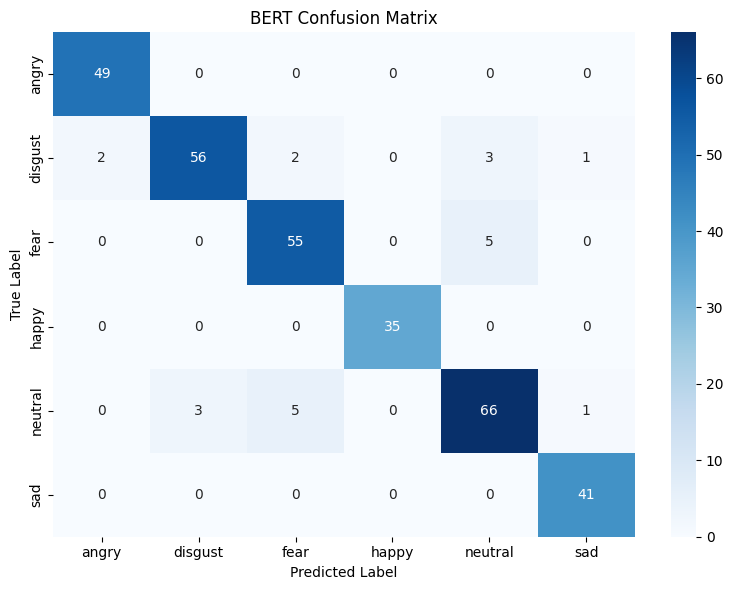

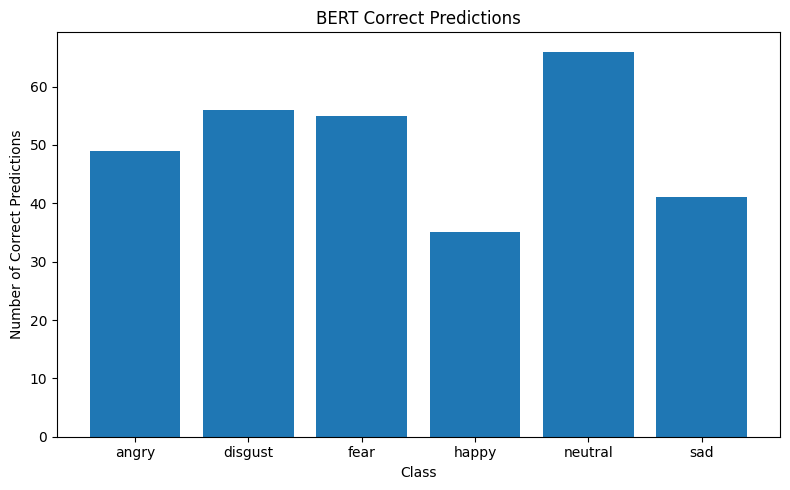


===== BERT + DEEPSEEK =====
Accuracy    : 0.9290123456790124
F1 Macro    : 0.9368028718142161
F1 Weighted : 0.9284608119992356

Classification Report:
              precision    recall  f1-score   support

       angry       0.98      1.00      0.99        49
     disgust       0.97      0.89      0.93        64
        fear       0.90      0.90      0.90        60
       happy       0.95      1.00      0.97        35
     neutral       0.89      0.87      0.88        75
         sad       0.91      1.00      0.95        41

    accuracy                           0.93       324
   macro avg       0.93      0.94      0.94       324
weighted avg       0.93      0.93      0.93       324

Confusion Matrix:
[[49  0  0  0  0  0]
 [ 1 57  1  0  2  3]
 [ 0  0 54  0  6  0]
 [ 0  0  0 35  0  0]
 [ 0  2  5  2 65  1]
 [ 0  0  0  0  0 41]]


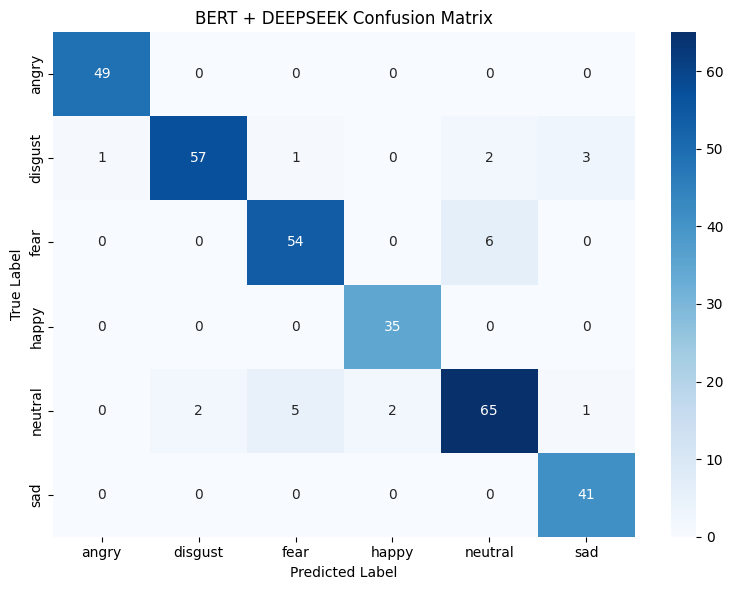

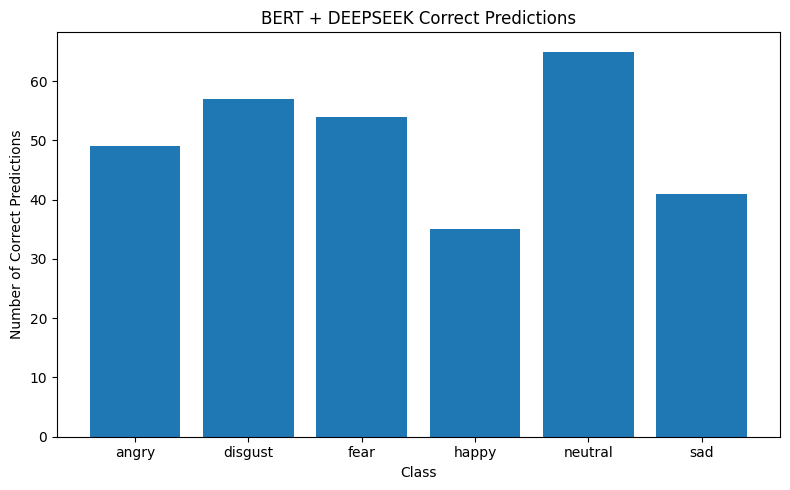


===== TRANSFORMER: RoBERTa =====
Columns: ['row_id', 'text', 'label', 'roberta_pred', 'roberta_confidence']

===== RoBERTa =====
Accuracy    : 0.9382716049382716
F1 Macro    : 0.9484147715858257
F1 Weighted : 0.937734902686384

Classification Report:
              precision    recall  f1-score   support

       angry       0.98      1.00      0.99        49
     disgust       0.94      0.97      0.95        64
        fear       0.87      0.88      0.88        60
       happy       1.00      1.00      1.00        35
     neutral       0.91      0.85      0.88        75
         sad       0.98      1.00      0.99        41

    accuracy                           0.94       324
   macro avg       0.95      0.95      0.95       324
weighted avg       0.94      0.94      0.94       324

Confusion Matrix:
[[49  0  0  0  0  0]
 [ 0 62  1  0  0  1]
 [ 0  1 53  0  6  0]
 [ 0  0  0 35  0  0]
 [ 1  3  7  0 64  0]
 [ 0  0  0  0  0 41]]


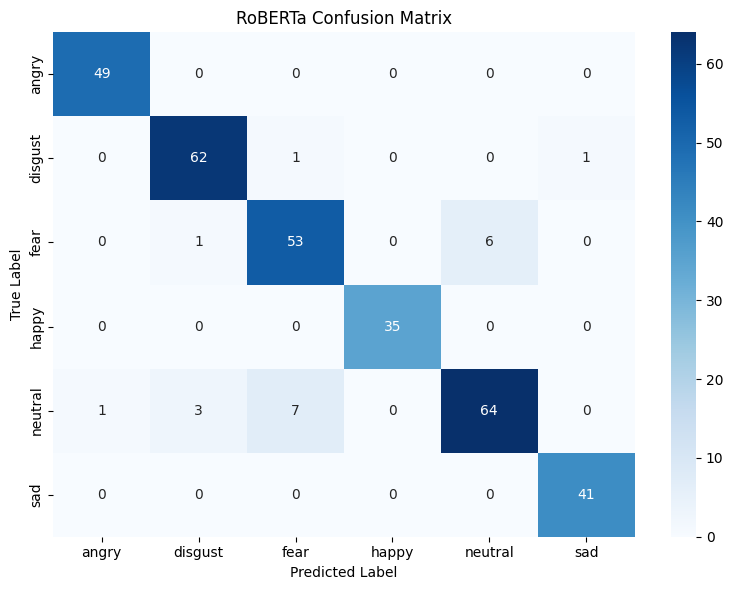

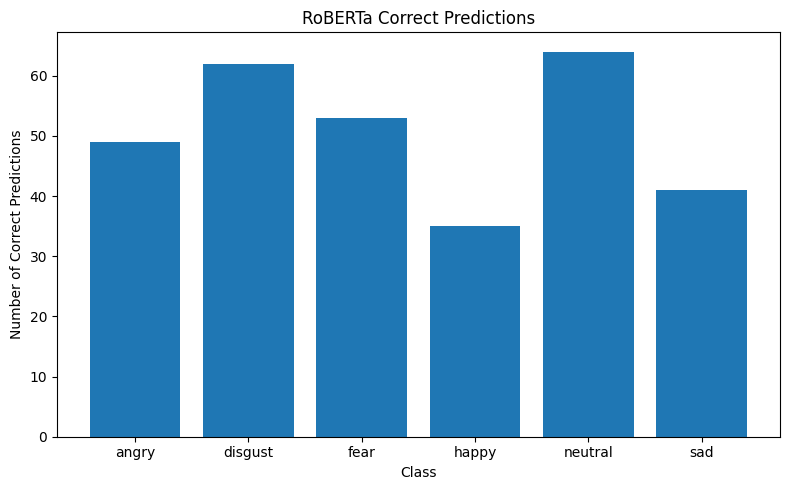


===== RoBERTa + DEEPSEEK =====
Accuracy    : 0.9320987654320988
F1 Macro    : 0.9417550592338512
F1 Weighted : 0.9313843349230906

Classification Report:
              precision    recall  f1-score   support

       angry       1.00      1.00      1.00        49
     disgust       0.95      0.97      0.96        64
        fear       0.88      0.83      0.85        60
       happy       0.97      1.00      0.99        35
     neutral       0.88      0.87      0.87        75
         sad       0.95      1.00      0.98        41

    accuracy                           0.93       324
   macro avg       0.94      0.94      0.94       324
weighted avg       0.93      0.93      0.93       324

Confusion Matrix:
[[49  0  0  0  0  0]
 [ 0 62  1  0  0  1]
 [ 0  1 50  0  9  0]
 [ 0  0  0 35  0  0]
 [ 0  2  6  1 65  1]
 [ 0  0  0  0  0 41]]


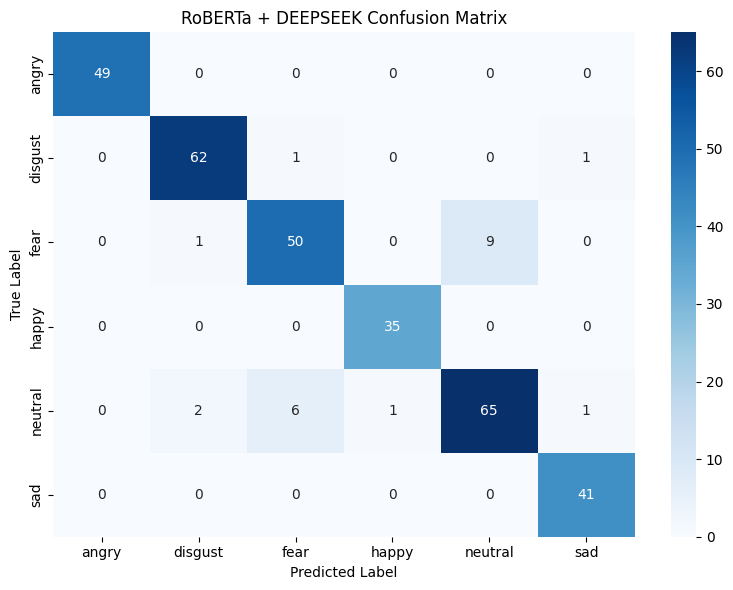

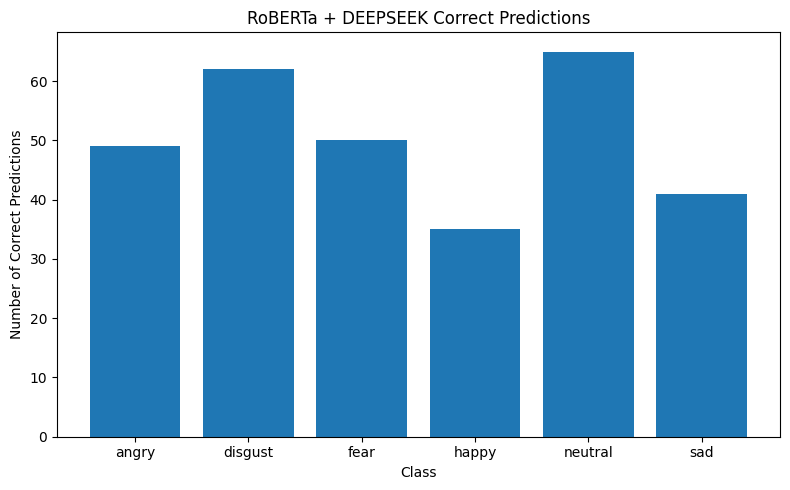


===== TRANSFORMER: ClinicalBERT =====
Columns: ['row_id', 'text', 'label', 'clinicalbert_pred', 'clinicalbert_confidence']

===== ClinicalBERT =====
Accuracy    : 0.9074074074074074
F1 Macro    : 0.9181348987472253
F1 Weighted : 0.9063929414126755

Classification Report:
              precision    recall  f1-score   support

       angry       0.94      1.00      0.97        49
     disgust       0.92      0.86      0.89        64
        fear       0.84      0.82      0.83        60
       happy       1.00      1.00      1.00        35
     neutral       0.89      0.87      0.88        75
         sad       0.89      1.00      0.94        41

    accuracy                           0.91       324
   macro avg       0.91      0.92      0.92       324
weighted avg       0.91      0.91      0.91       324

Confusion Matrix:
[[49  0  0  0  0  0]
 [ 1 55  4  0  0  4]
 [ 0  3 49  0  8  0]
 [ 0  0  0 35  0  0]
 [ 2  2  5  0 65  1]
 [ 0  0  0  0  0 41]]


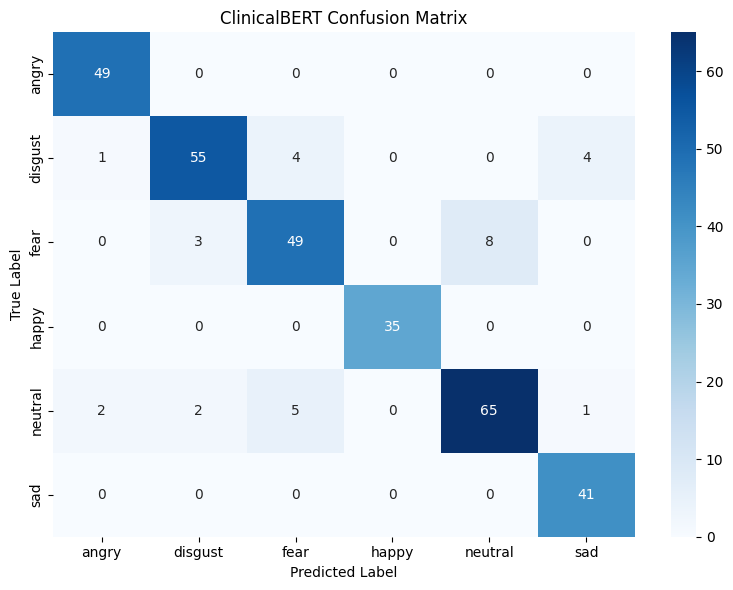

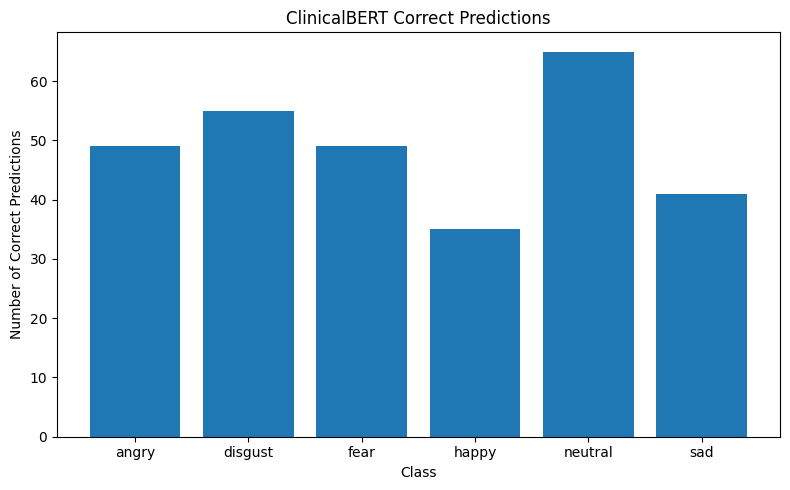


===== ClinicalBERT + DEEPSEEK =====
Accuracy    : 0.9135802469135802
F1 Macro    : 0.9232317051659514
F1 Weighted : 0.9125130614425669

Classification Report:
              precision    recall  f1-score   support

       angry       0.98      1.00      0.99        49
     disgust       0.95      0.89      0.92        64
        fear       0.85      0.78      0.82        60
       happy       0.95      1.00      0.97        35
     neutral       0.86      0.89      0.88        75
         sad       0.93      1.00      0.96        41

    accuracy                           0.91       324
   macro avg       0.92      0.93      0.92       324
weighted avg       0.91      0.91      0.91       324

Confusion Matrix:
[[49  0  0  0  0  0]
 [ 1 57  3  0  0  3]
 [ 0  2 47  0 11  0]
 [ 0  0  0 35  0  0]
 [ 0  1  5  2 67  0]
 [ 0  0  0  0  0 41]]


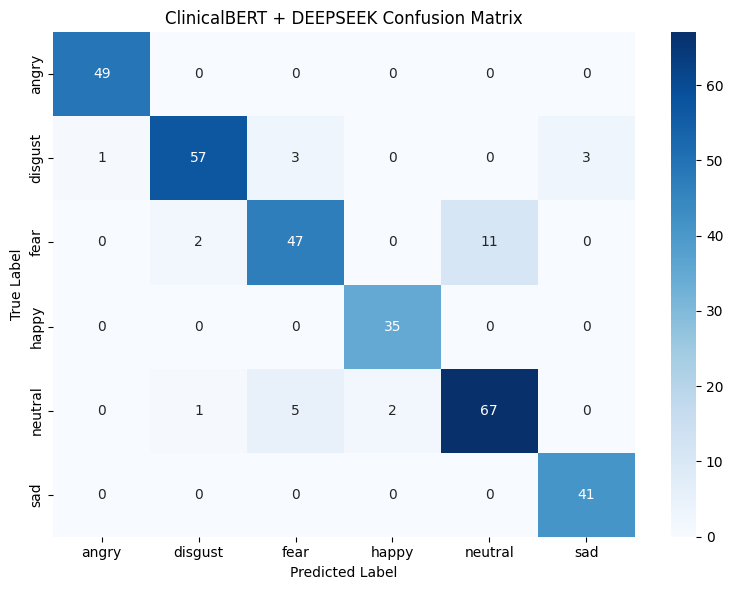

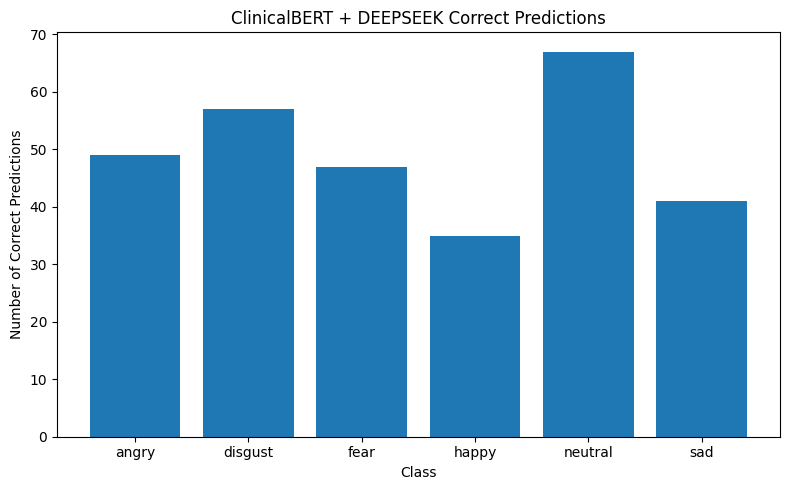

In [16]:
for model_name, file_path in TRANSFORMER_FILES.items():
    print(f"\n===== TRANSFORMER: {model_name} =====")

    pred_df = pd.read_csv(file_path)
    print("Columns:", pred_df.columns.tolist())

    merged_df = test_df[["row_id", "text", "label"]].merge(
        pred_df,
        on="row_id",
        how="left"
    )

    pred_col, conf_col = COLUMN_MAP[model_name]


    transformer_preds = merged_df[pred_col].fillna("neutral").tolist()
    transformer_confs = merged_df[conf_col].fillna(0).astype(float).tolist()

    result_df[f"{model_name.lower()}_pred"] = transformer_preds
    result_df[f"{model_name.lower()}_confidence"] = transformer_confs

    print_model_result(y_true, transformer_preds, model_name, labels)
    summary_rows.append(get_summary_metrics(y_true, transformer_preds, model_name))
    per_class_frames.append(get_per_class_report(y_true, transformer_preds, model_name, labels))

    plot_confusion_matrix(
        y_true,
        transformer_preds,
        labels,
        title=f"{model_name} Confusion Matrix"
    )

    plot_confusion_bar_chart(
        y_true,
        transformer_preds,
        labels,
        title=f"{model_name} Correct Predictions"
    )

    hybrid_start = time.time()
    final_transformer_preds = []

    for text, pred, conf in zip(texts, transformer_preds, transformer_confs):
        if USE_LLM and conf < CONF_THRESHOLD:
            new_pred = llm_refine(
                text=text,
                pred_label=pred,
                allowed_labels=labels,
                few_shot_prompt=few_shot_prompt
            )
        else:
            new_pred = pred

        final_transformer_preds.append(new_pred)

    hybrid_elapsed = time.time() - hybrid_start

    hybrid_name = f"{model_name} + {LLM_NAME.upper()}"
    result_df[f"{model_name.lower()}_hybrid_pred"] = final_transformer_preds

    print_model_result(y_true, final_transformer_preds, hybrid_name, labels)
    summary_rows.append(get_summary_metrics(y_true, final_transformer_preds, hybrid_name, hybrid_elapsed))
    per_class_frames.append(get_per_class_report(y_true, final_transformer_preds, hybrid_name, labels))

    plot_confusion_matrix(
        y_true,
        final_transformer_preds,
        labels,
        title=f"{hybrid_name} Confusion Matrix"
    )

    plot_confusion_bar_chart(
        y_true,
        final_transformer_preds,
        labels,
        title=f"{hybrid_name} Correct Predictions"
    )

### Final tables

In [17]:
summary_df = pd.DataFrame(summary_rows).sort_values(
    by=["Accuracy", "F1_Macro"],
    ascending=False
).reset_index(drop=True)

per_class_df = pd.concat(per_class_frames, ignore_index=True)

print("\n===== FINAL SUMMARY =====")
print(summary_df)

result_df.to_csv(OUTPUT_PRED_FILE, index=False, encoding="utf-8-sig")
summary_df.to_csv(OUTPUT_SUMMARY_FILE, index=False, encoding="utf-8-sig")
per_class_df.to_csv(OUTPUT_PER_CLASS_FILE, index=False, encoding="utf-8-sig")

total_elapsed = time.time() - total_start_time

hours = int(total_elapsed // 3600)
minutes = int((total_elapsed % 3600) // 60)
seconds = int(total_elapsed % 60)

print("\nSaved:")
print("-", OUTPUT_PRED_FILE)
print("-", OUTPUT_SUMMARY_FILE)
print("-", OUTPUT_PER_CLASS_FILE)
print(f"\nTotal hybrid pipeline time: {total_elapsed:.2f} seconds")
print(f"\nTotal hybrid pipeline time: {hours}h {minutes}m {seconds}s")
print("Done")


===== FINAL SUMMARY =====
                                Model  Accuracy  F1_Macro  F1_Weighted  \
0                             RoBERTa  0.938272  0.948415     0.937735   
1                                BERT  0.932099  0.942384     0.931671   
2                  RoBERTa + DEEPSEEK  0.932099  0.941755     0.931384   
3                     BERT + DEEPSEEK  0.929012  0.936803     0.928461   
4   Support Vector Machine + DEEPSEEK  0.925926  0.932232     0.924638   
5                   BiLSTM + DEEPSEEK  0.916667  0.926127     0.915209   
6             ClinicalBERT + DEEPSEEK  0.913580  0.923232     0.912513   
7                        ClinicalBERT  0.907407  0.918135     0.906393   
8              Support Vector Machine  0.904321  0.919068     0.903556   
9              Naive Bayes + DEEPSEEK  0.901235  0.907439     0.900173   
10                Logistic Regression  0.895062  0.912052     0.894449   
11                             BiLSTM  0.895062  0.905452     0.892672   
12     Logi

In [26]:
import sys

!{sys.executable} -m pip install statsmodels


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import pandas as pd
from statsmodels.stats.contingency_tables import mcnemar

pred_df = pd.read_csv(OUTPUT_PRED_FILE)

y_true = pred_df["label"]

LLM_LABEL = LLM_NAME.upper()

comparisons = {
    f"Naive Bayes vs Naive Bayes + {LLM_LABEL}":
        ("naive_bayes_pred", "naive_bayes_hybrid_pred"),

    f"Logistic Regression vs Logistic Regression + {LLM_LABEL}":
        ("logistic_regression_pred", "logistic_regression_hybrid_pred"),

    f"Random Forest vs Random Forest + {LLM_LABEL}":
        ("random_forest_pred", "random_forest_hybrid_pred"),

    f"SVM vs SVM + {LLM_LABEL}":
        ("support_vector_machine_pred", "support_vector_machine_hybrid_pred"),

    f"BiLSTM vs BiLSTM + {LLM_LABEL}":
        ("dl_pred", "dl_hybrid_pred"),

    f"BERT vs BERT + {LLM_LABEL}":
        ("bert_pred", "bert_hybrid_pred"),

    f"RoBERTa vs RoBERTa + {LLM_LABEL}":
        ("roberta_pred", "roberta_hybrid_pred"),

    f"ClinicalBERT vs ClinicalBERT + {LLM_LABEL}":
        ("clinicalbert_pred", "clinicalbert_hybrid_pred"),
}
rows = []

for name, (base_col, hybrid_col) in comparisons.items():
    base_correct = pred_df[base_col] == y_true
    hybrid_correct = pred_df[hybrid_col] == y_true

    b = ((base_correct == True) & (hybrid_correct == False)).sum()
    c = ((base_correct == False) & (hybrid_correct == True)).sum()

    table = [[0, b], [c, 0]]

    result = mcnemar(table, exact=True)

    rows.append({
        "Comparison": name,
        "Base Correct / Hybrid Wrong": b,
        "Base Wrong / Hybrid Correct": c,
        "p_value": result.pvalue,
        "Significant": "Yes" if result.pvalue < 0.05 else "No"
    })

mcnemar_df = pd.DataFrame(rows)

mcnemar_df.to_csv(
    OUTPUT_MCNEMAR_FILE,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", OUTPUT_MCNEMAR_FILE)

mcnemar_df

Saved: ../data/processed/mcnemar_deepseek_results.csv


,Comparison,Base Correct / Hybrid Wrong,Base Wrong / Hybrid Correct,p_value,Significant
0,Naive Bayes vs Naive Bayes + DEEPSEEK,14,20,0.391528,No
1,Logistic Regression vs Logistic Regression + D...,16,16,1.000000,No
2,Random Forest vs Random Forest + DEEPSEEK,10,16,0.326940,No
3,SVM vs SVM + DEEPSEEK,3,10,0.092285,No
4,BiLSTM vs BiLSTM + DEEPSEEK,4,11,0.118469,No
5,BERT vs BERT + DEEPSEEK,2,1,1.000000,No
6,RoBERTa vs RoBERTa + DEEPSEEK,5,3,0.726562,No
7,ClinicalBERT vs ClinicalBERT + DEEPSEEK,3,5,0.726562,No


### ADDITIONAL PLOTS: ALL BASELINE VS HYBRID MODELS


===== PLOTS: Naive Bayes =====


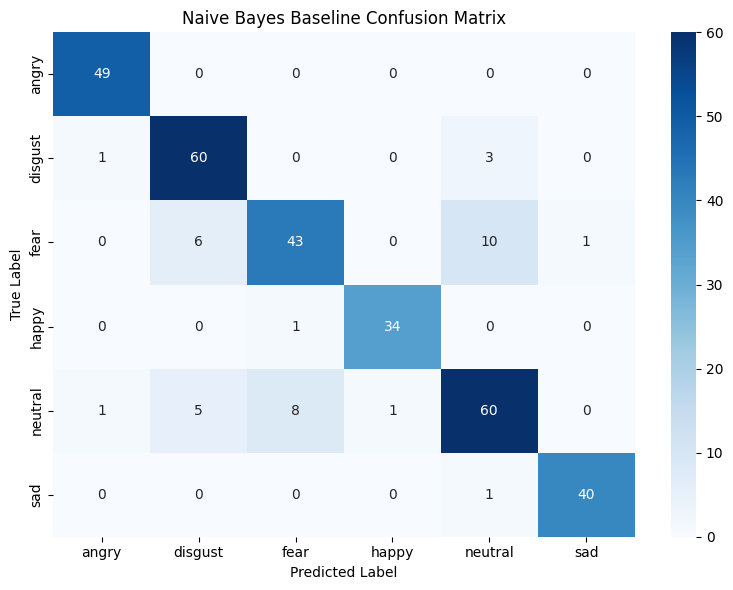

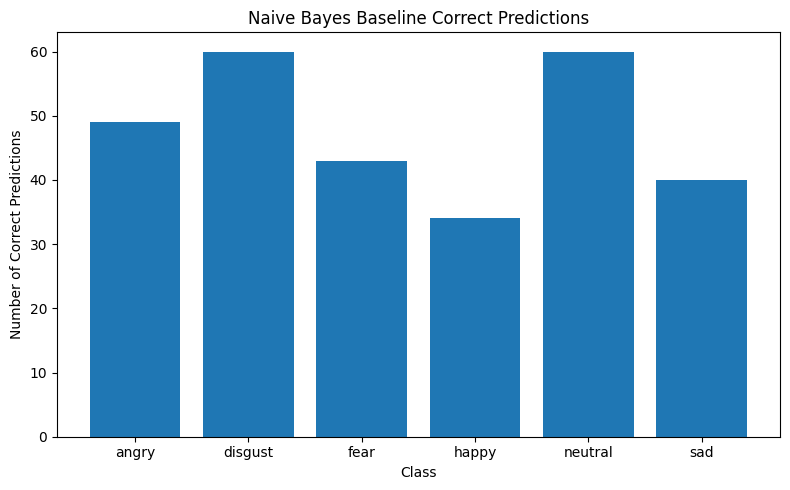

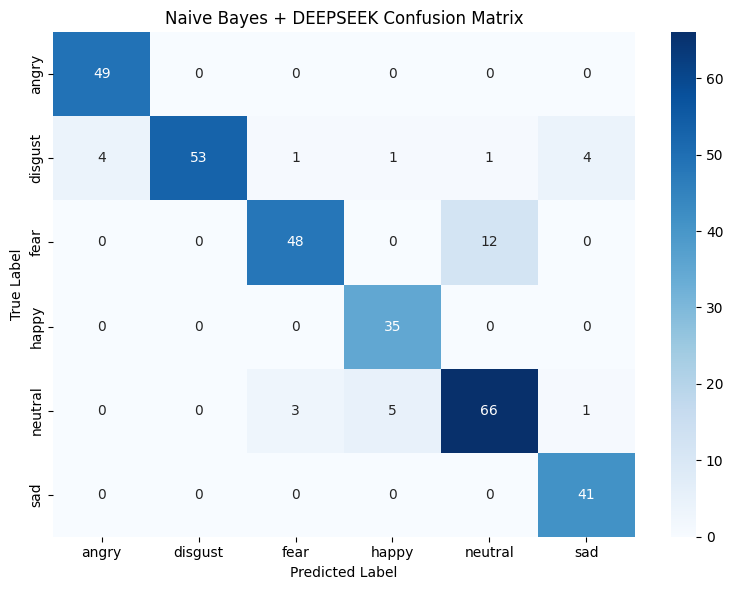

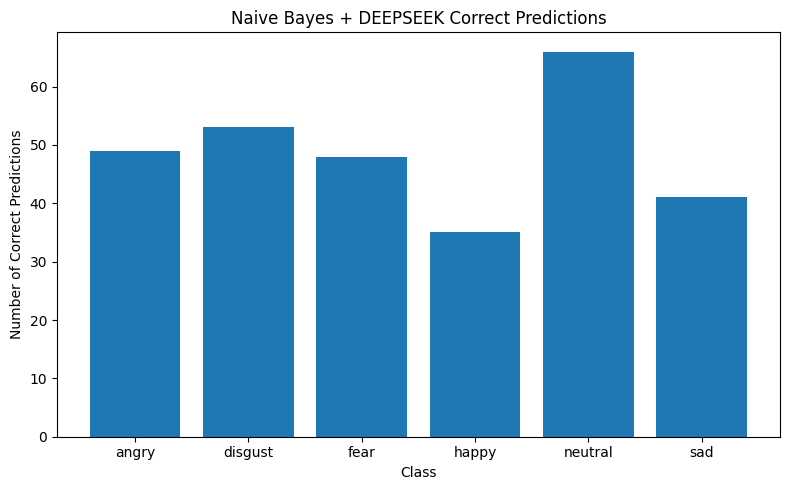


===== PLOTS: Logistic Regression =====


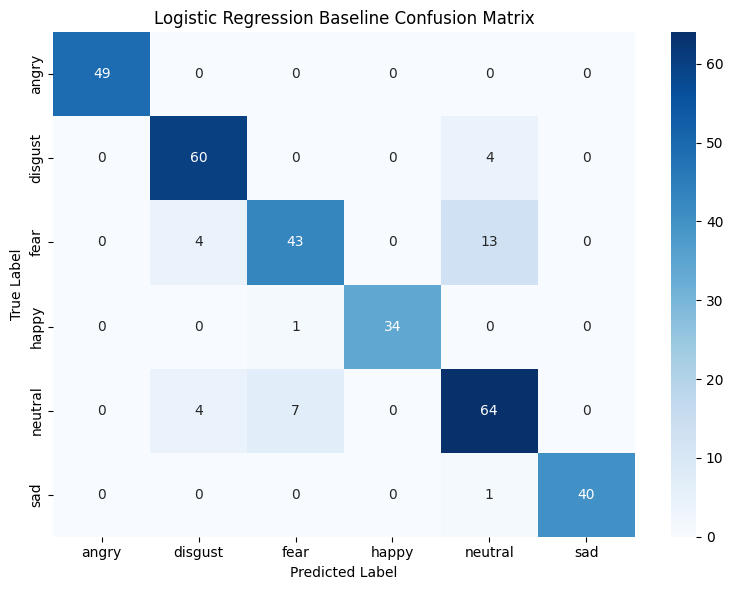

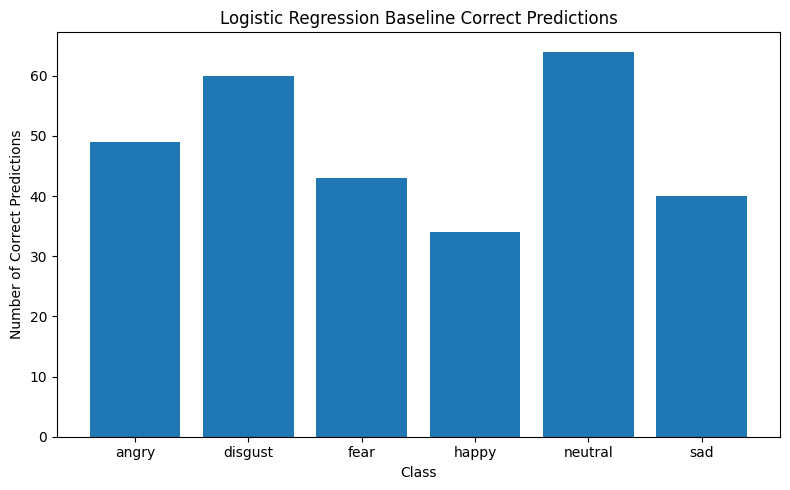

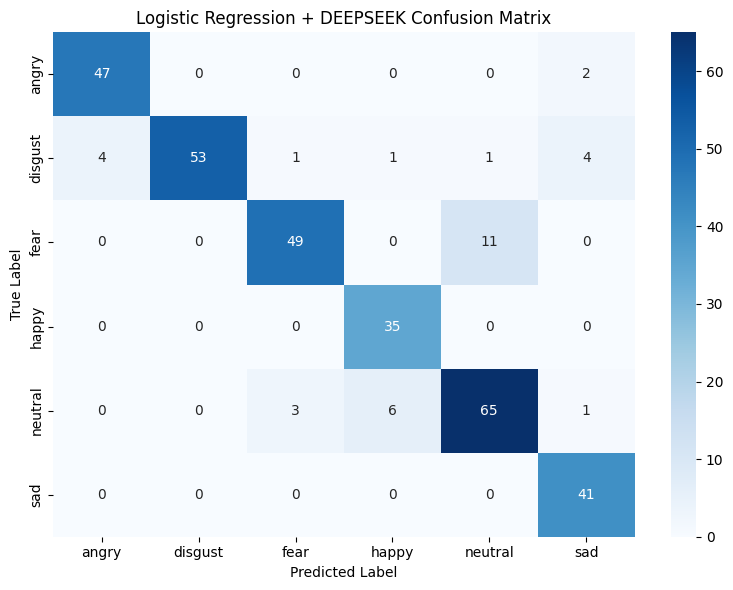

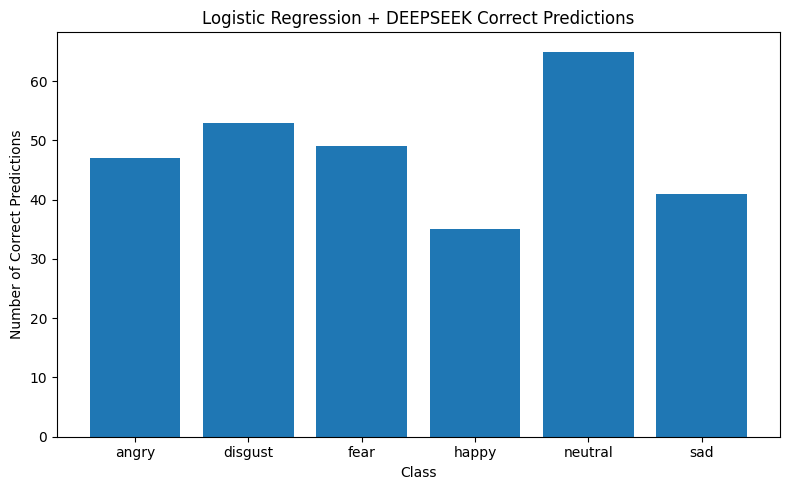


===== PLOTS: Random Forest =====


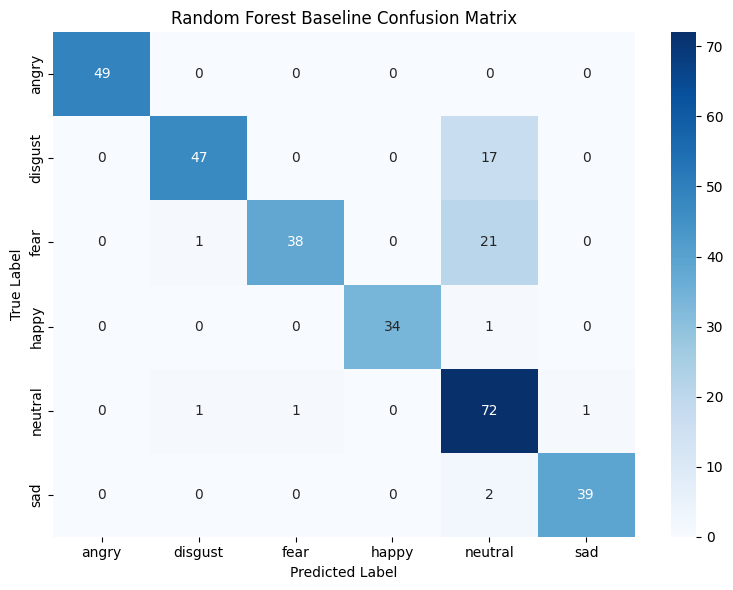

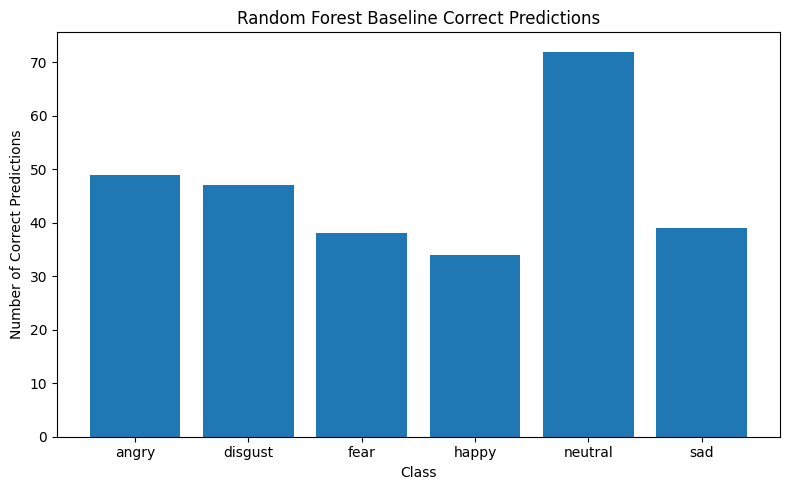

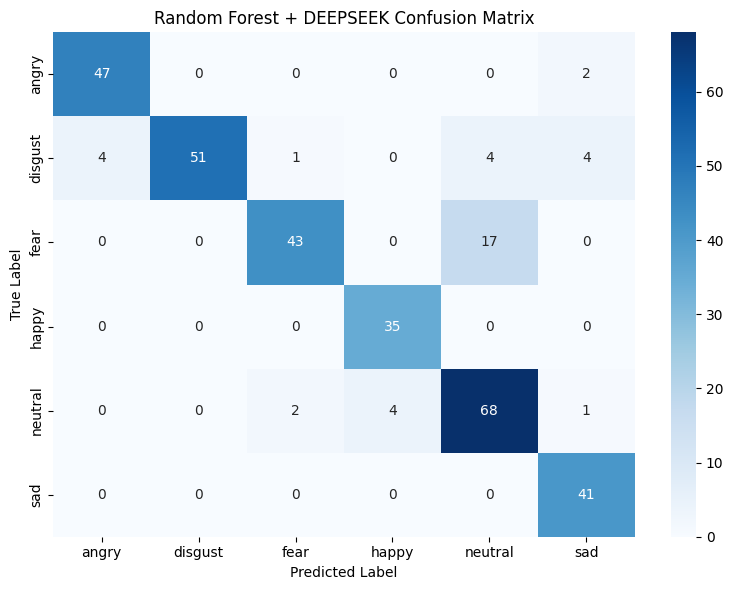

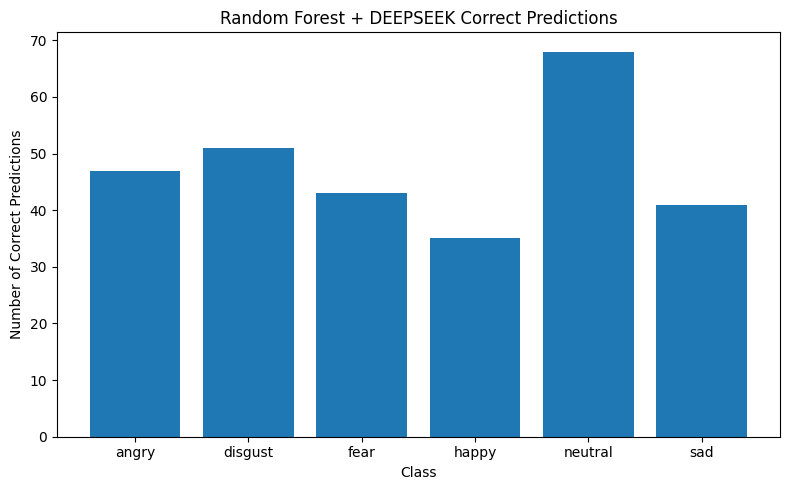


===== PLOTS: SVM =====


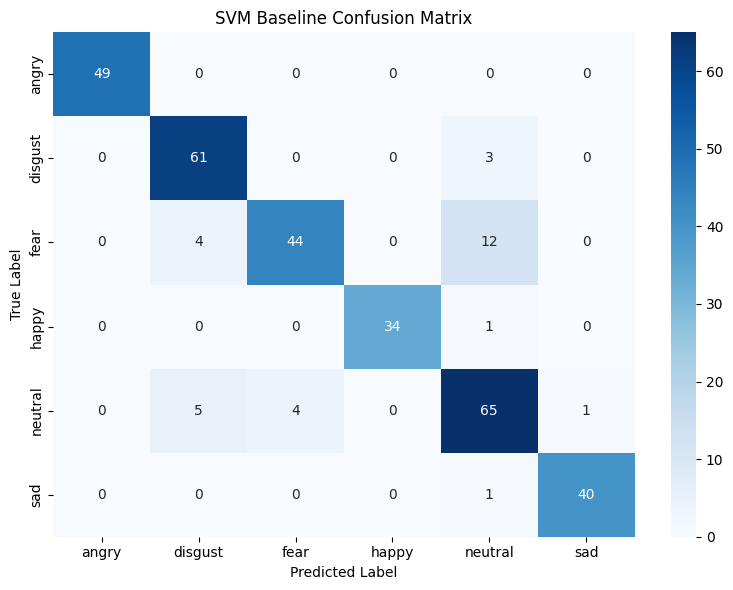

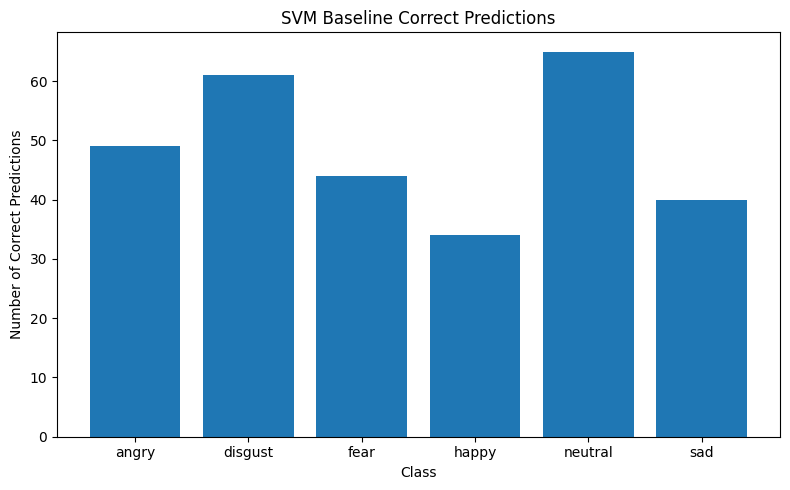

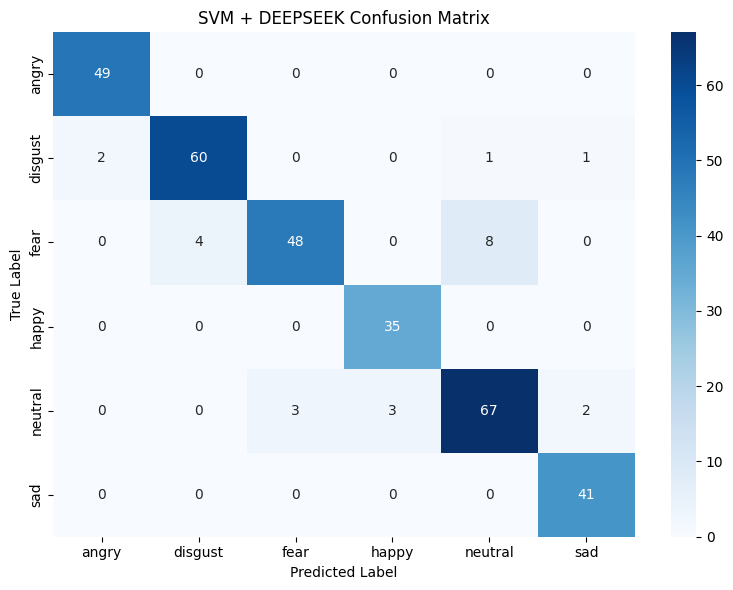

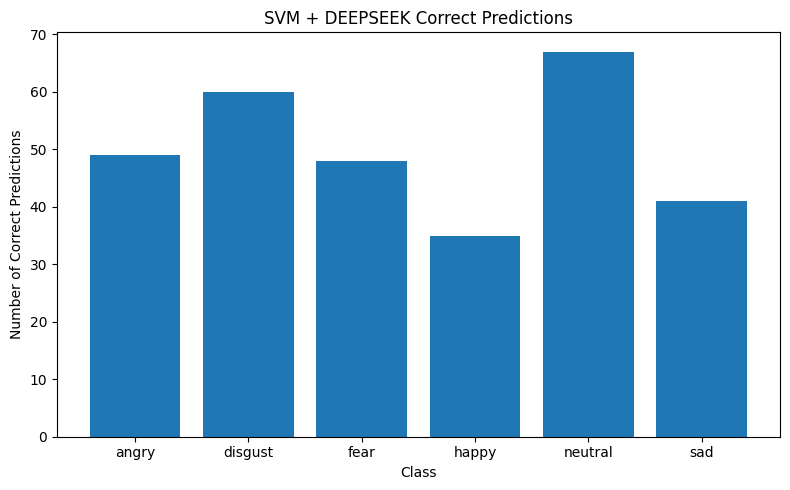


===== PLOTS: BiLSTM =====


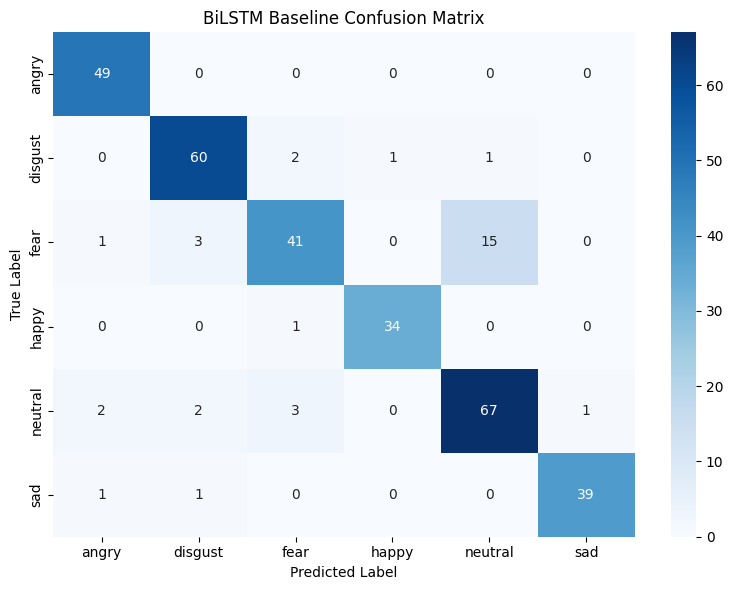

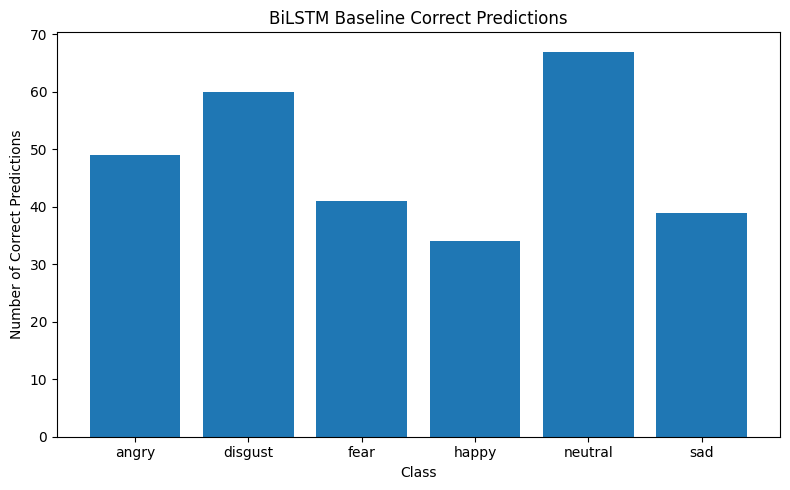

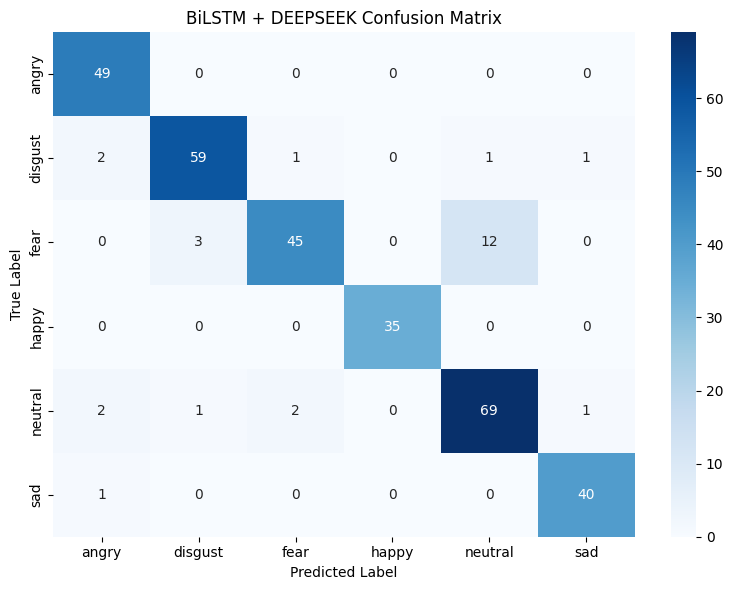

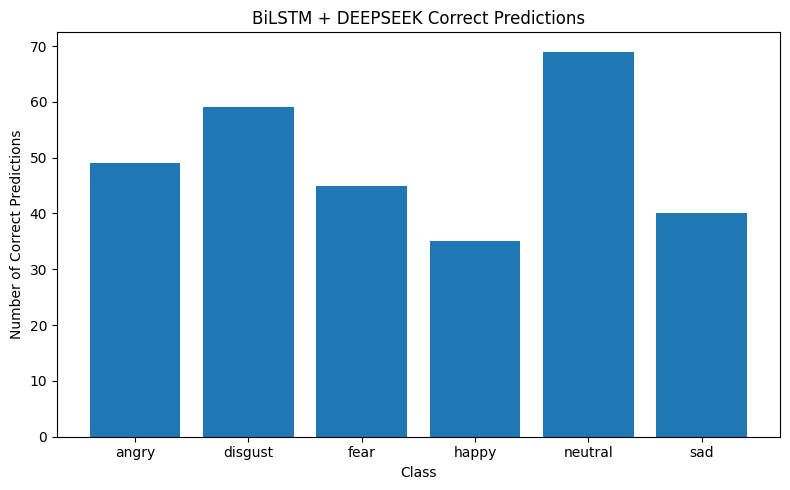


===== PLOTS: BERT =====


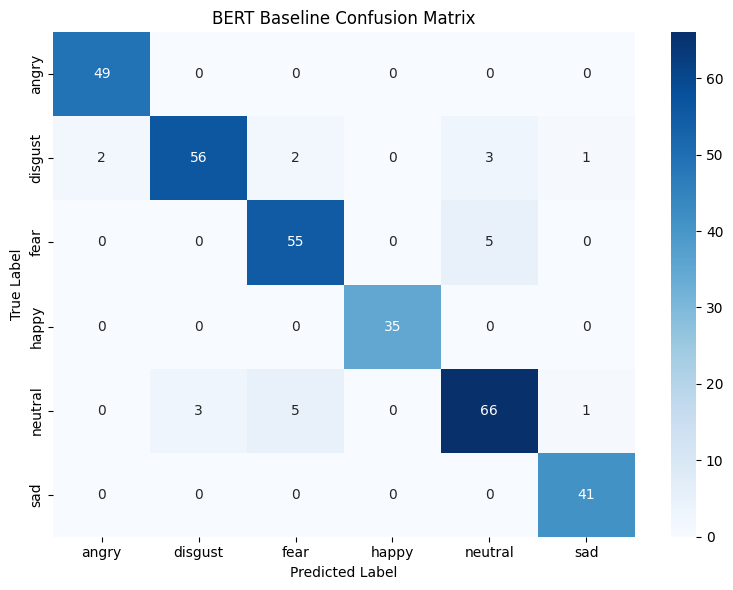

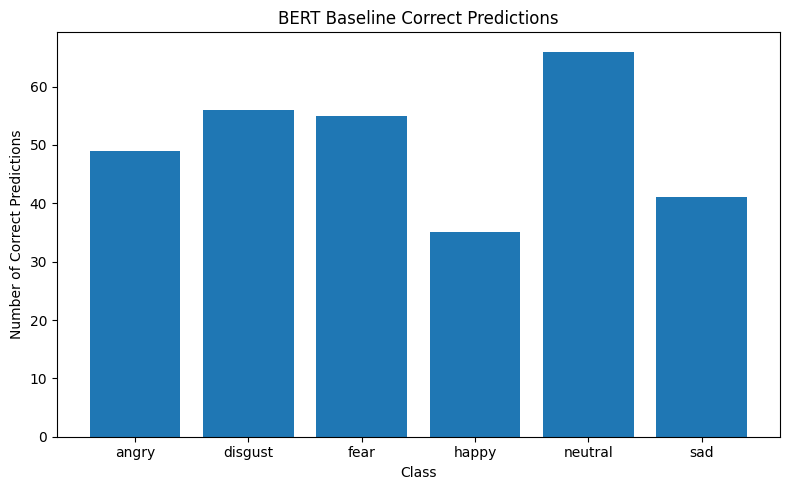

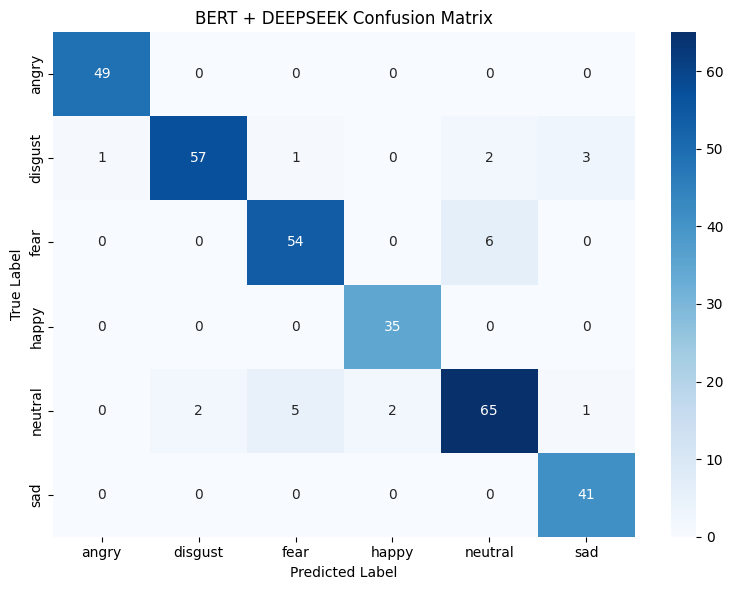

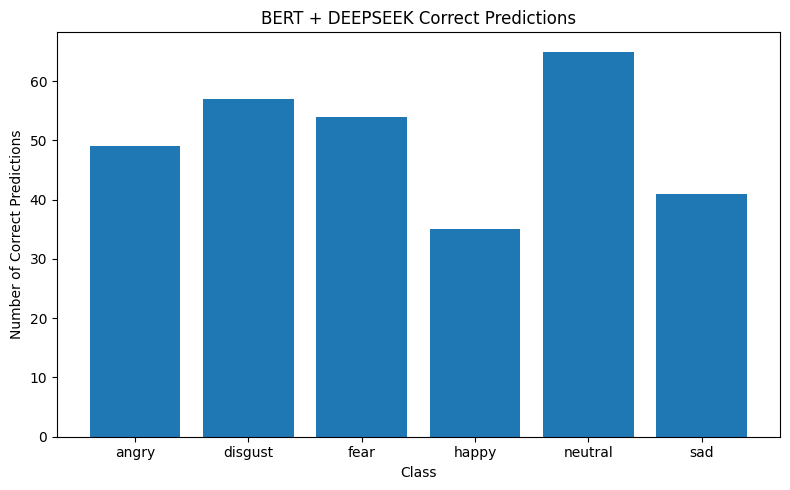


===== PLOTS: RoBERTa =====


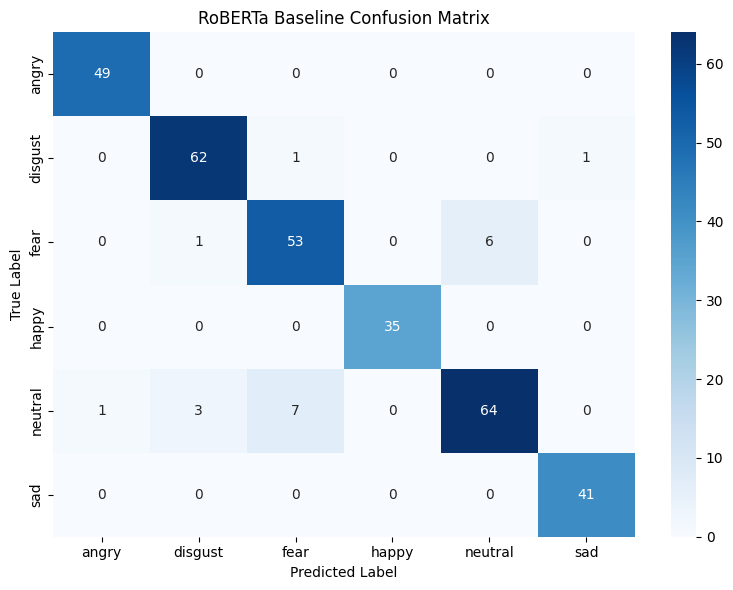

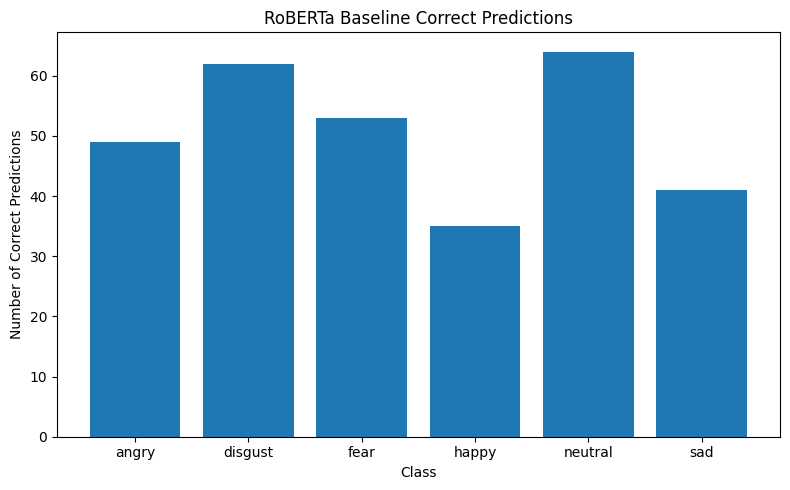

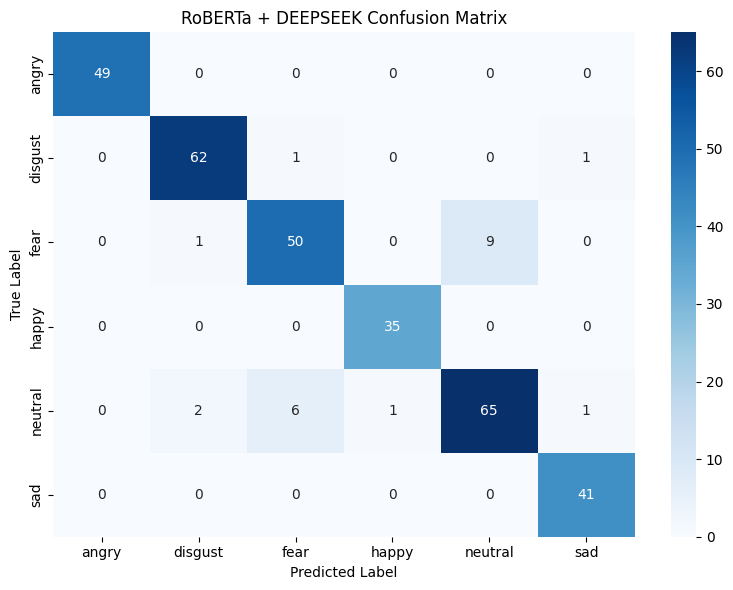

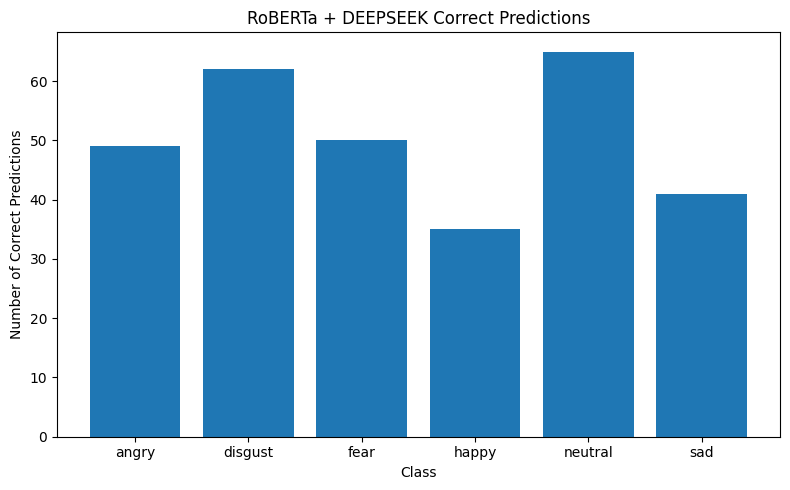


===== PLOTS: ClinicalBERT =====


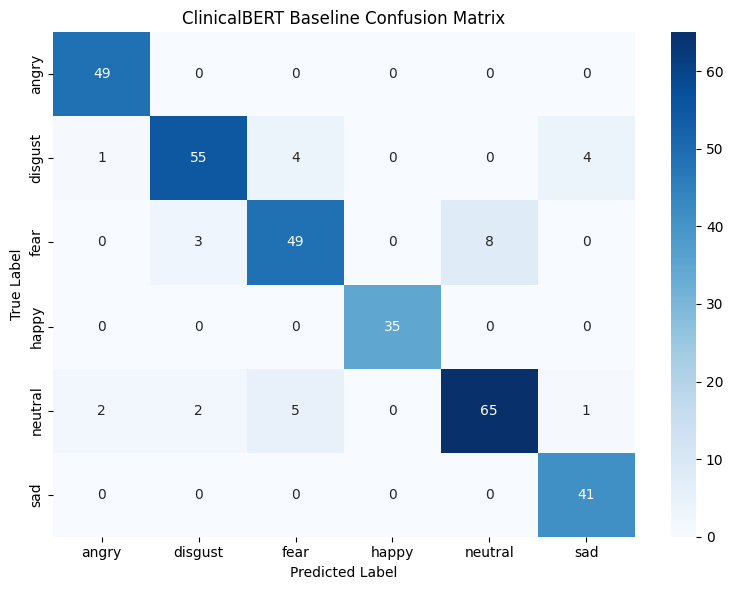

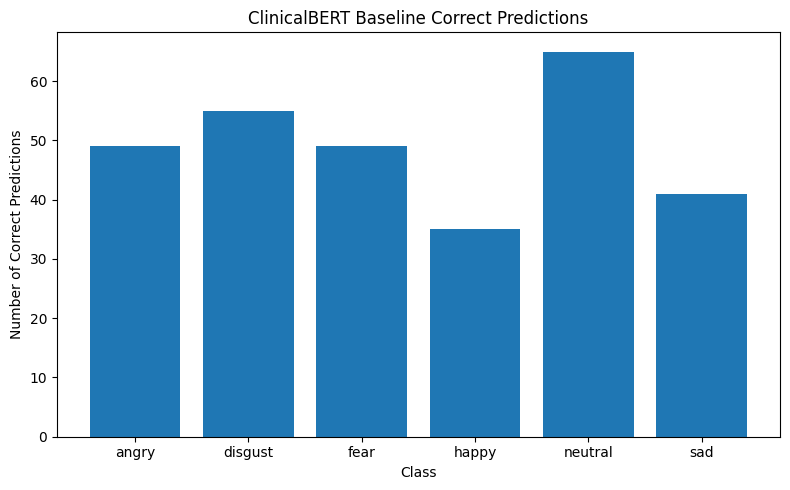

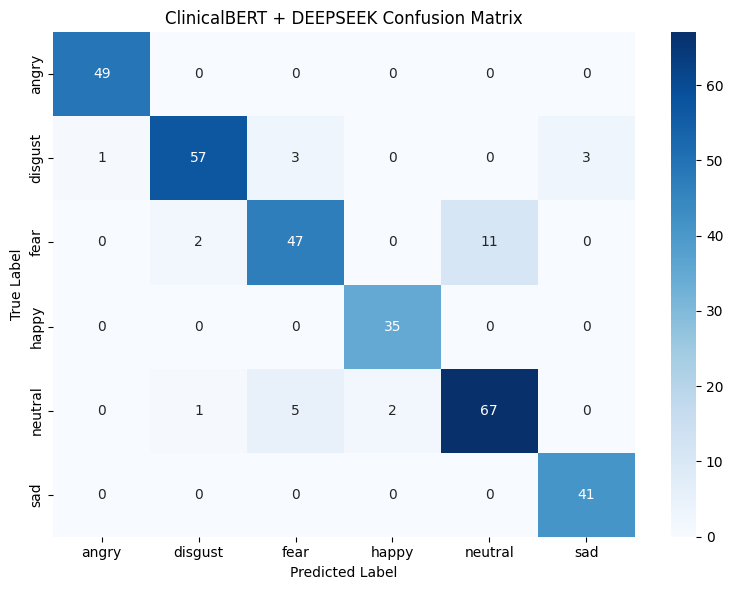

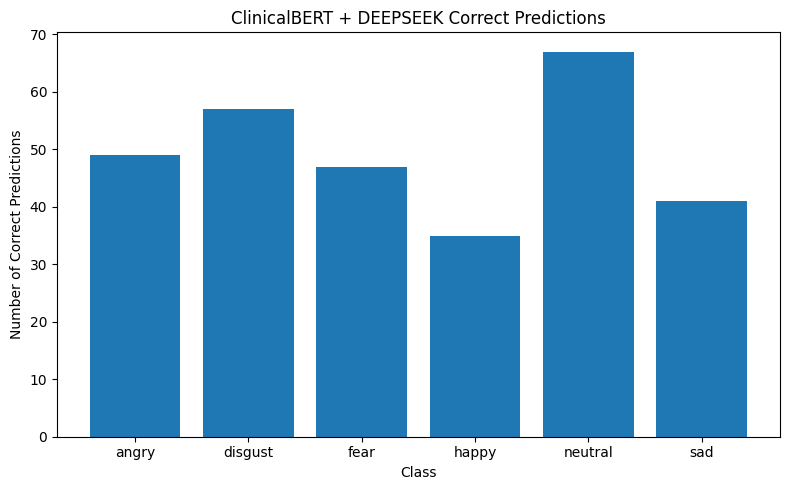

In [23]:
# =========================
# ADDITIONAL PLOTS: ALL BASELINE VS HYBRID MODELS
# =========================

llm_label = LLM_NAME.upper()

PLOT_COMPARISONS = {
    "Naive Bayes": ("naive_bayes_pred", "naive_bayes_hybrid_pred"),
    "Logistic Regression": ("logistic_regression_pred", "logistic_regression_hybrid_pred"),
    "Random Forest": ("random_forest_pred", "random_forest_hybrid_pred"),
    "SVM": ("support_vector_machine_pred", "support_vector_machine_hybrid_pred"),
    "BiLSTM": ("dl_pred", "dl_hybrid_pred"),
    "BERT": ("bert_pred", "bert_hybrid_pred"),
    "RoBERTa": ("roberta_pred", "roberta_hybrid_pred"),
    "ClinicalBERT": ("clinicalbert_pred", "clinicalbert_hybrid_pred"),
}

for model_display_name, (base_col, hybrid_col) in PLOT_COMPARISONS.items():
    print(f"\n===== PLOTS: {model_display_name} =====")

    if base_col not in result_df.columns:
        print(f"Skip {model_display_name}: missing {base_col}")
        continue

    if hybrid_col not in result_df.columns:
        print(f"Skip {model_display_name}: missing {hybrid_col}")
        continue

    # Baseline
    plot_confusion_matrix(
        y_true,
        result_df[base_col],
        labels,
        title=f"{model_display_name} Baseline Confusion Matrix"
    )

    plot_confusion_bar_chart(
        y_true,
        result_df[base_col],
        labels,
        title=f"{model_display_name} Baseline Correct Predictions"
    )

    # Hybrid
    plot_confusion_matrix(
        y_true,
        result_df[hybrid_col],
        labels,
        title=f"{model_display_name} + {llm_label} Confusion Matrix"
    )

    plot_confusion_bar_chart(
        y_true,
        result_df[hybrid_col],
        labels,
        title=f"{model_display_name} + {llm_label} Correct Predictions"
    )